# Evaluation Dimension Correlation Analysis

Computes Spearman rank correlation and Kendall tau correlation across evaluation dimensions.

**단위:** 개별 QA (모델 무관) — 완료된 모델 6개 × 868 QA = ~5,208개 데이터 포인트  
**Judge:** `qwen3_1.7b_judge_Qwen3.5-9B` / **Subset:** `opp_200`

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path("/NAS/wonjun/exp_implexconv_no_response/evaluation/qwen3_1.7b_judge_Qwen3.5-9B/opp_200")

## 1. Load all QA-level scores (across all completed models)

In [2]:
summary_df = pd.read_csv(BASE_DIR / "judge_summary.csv")
completed_models = summary_df[summary_df["judge_calls"] > 0]["model"].tolist()
print(f"Completed models ({len(completed_models)}): {completed_models}")

DIMS = [
    "rc_question_addressing",
    "rc_specificity",
    "rc_consistency",
    "pa_persona_recognition",
    "pa_generic_distinctness",
    "pa_persona_specificity",
    "pa_substantive_integration",
]

def load_model_scores(model_name: str) -> pd.DataFrame:
    path = BASE_DIR / f"judge_scores_{model_name}_Qwen3-1.7B.json"
    with open(path) as f:
        sessions = json.load(f)
    rows = []
    for session in sessions:
        for qa in session["qa_scores"]:
            if not qa.get("judge_eligible", True):
                continue
            if not qa.get("valid", True):
                continue
            row = {"model": model_name, "session_id": session["session_id"]}
            for dim in DIMS:
                row[dim] = qa.get(dim)
            rows.append(row)
    return pd.DataFrame(rows)

dfs = [load_model_scores(m) for m in completed_models]
all_scores = pd.concat(dfs, ignore_index=True)

# Drop rows where any dim is None/NaN
all_scores = all_scores.dropna(subset=DIMS)

print(f"\nTotal QA records (n * m): {len(all_scores)}")
print(f"  models (m): {len(completed_models)}, QA per model (n): {len(all_scores) // len(completed_models)}")
all_scores[DIMS].describe()

Completed models (6): ['amem', 'lbllm', 'ldagent', 'memorybank', 'theanine', 'ubllm']

Total QA records (n * m): 5208
  models (m): 6, QA per model (n): 868


,rc_question_addressing,rc_specificity,rc_consistency,pa_persona_recognition,pa_generic_distinctness,pa_persona_specificity,pa_substantive_integration
count,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000,5208.000000
mean,0.940284,0.797619,0.981375,0.035522,0.014401,0.026498,0.008257
std,0.236982,0.401813,0.135210,0.185114,0.119148,0.160625,0.090498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Spearman Rank Correlation (QA-level)

In [3]:
n_dims = len(DIMS)
scores_arr = all_scores[DIMS].values  # shape: (n*m, 7)

spearman_mat = np.zeros((n_dims, n_dims))
spearman_pval = np.zeros((n_dims, n_dims))

for i in range(n_dims):
    for j in range(n_dims):
        res = stats.spearmanr(scores_arr[:, i], scores_arr[:, j])
        spearman_mat[i, j] = res.statistic
        spearman_pval[i, j] = res.pvalue

spearman_df = pd.DataFrame(spearman_mat, index=DIMS, columns=DIMS)
spearman_pval_df = pd.DataFrame(spearman_pval, index=DIMS, columns=DIMS)

print(f"Spearman correlation matrix (N={len(all_scores)} QA samples):")
spearman_df.round(4)

Spearman correlation matrix (N=5208 QA samples):


,rc_question_addressing,rc_specificity,rc_consistency,pa_persona_recognition,pa_generic_distinctness,pa_persona_specificity,pa_substantive_integration
rc_question_addressing,1.0000,0.1776,0.1271,0.0352,0.0033,-0.0240,0.0140
rc_specificity,0.1776,1.0000,0.0473,0.0063,-0.0073,-0.0121,-0.0121
rc_consistency,0.1271,0.0473,1.0000,0.0188,-0.0430,-0.0569,-0.0031
pa_persona_recognition,0.0352,0.0063,0.0188,1.0000,0.3599,0.3430,0.4067
pa_generic_distinctness,0.0033,-0.0073,-0.0430,0.3599,1.0000,0.5621,0.3630
pa_persona_specificity,-0.0240,-0.0121,-0.0569,0.3430,0.5621,1.0000,0.3285
pa_substantive_integration,0.0140,-0.0121,-0.0031,0.4067,0.3630,0.3285,1.0000


In [4]:
print("Spearman p-value matrix:")
spearman_pval_df.applymap(lambda x: f"{x:.2e}")

Spearman p-value matrix:


/tmp/ipykernel_2753810/3021894494.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  spearman_pval_df.applymap(lambda x: f"{x:.2e}")


,rc_question_addressing,rc_specificity,rc_consistency,pa_persona_recognition,pa_generic_distinctness,pa_persona_specificity,pa_substantive_integration
rc_question_addressing,0.00e+00,3.63e-38,3.32e-20,1.10e-02,8.14e-01,8.32e-02,3.11e-01
rc_specificity,3.63e-38,0.00e+00,6.46e-04,6.49e-01,5.98e-01,3.82e-01,3.81e-01
rc_consistency,3.32e-20,6.46e-04,0.00e+00,1.76e-01,1.93e-03,4.03e-05,8.22e-01
pa_persona_recognition,1.10e-02,6.49e-01,1.76e-01,0.00e+00,4.40e-159,1.13e-143,1.22e-206
pa_generic_distinctness,8.14e-01,5.98e-01,1.93e-03,4.40e-159,0.00e+00,0.00e+00,5.64e-162
pa_persona_specificity,8.32e-02,3.82e-01,4.03e-05,1.13e-143,0.00e+00,0.00e+00,3.01e-131
pa_substantive_integration,3.11e-01,3.81e-01,8.22e-01,1.22e-206,5.64e-162,3.01e-131,0.00e+00


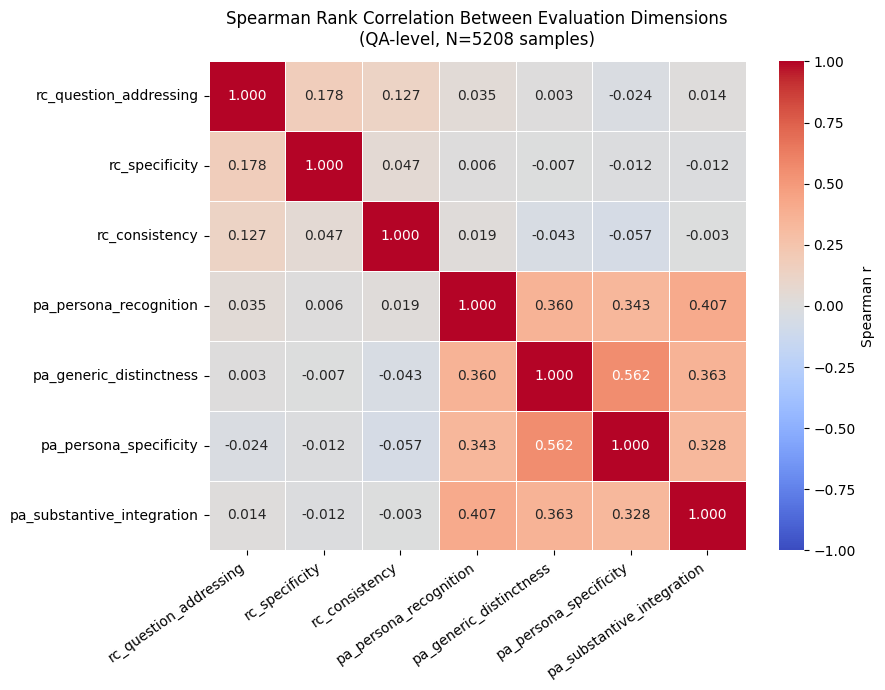

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
annot = np.array([
    [f"{spearman_mat[i,j]:.3f}" for j in range(n_dims)]
    for i in range(n_dims)
])
sns.heatmap(
    spearman_df, annot=annot, fmt="", cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Spearman r"},
)
ax.set_title(f"Spearman Rank Correlation Between Evaluation Dimensions\n(QA-level, N={len(all_scores)} samples)", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.savefig(BASE_DIR.parent / "spearman_correlation_dims_qa.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Kendall Tau Correlation (QA-level)

> ⚠️ N이 크면 Kendall tau 계산이 느릴 수 있음 (O(N²)). 샘플링 옵션도 제공.

In [6]:
# Kendall tau on full data (may take ~30s–2min for N~5000)
# Set USE_SAMPLE=True and SAMPLE_N to subsample if too slow
USE_SAMPLE = False
SAMPLE_N = 2000

if USE_SAMPLE:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(scores_arr), size=SAMPLE_N, replace=False)
    kendall_arr = scores_arr[idx]
    print(f"Using sample of {SAMPLE_N} / {len(scores_arr)} rows")
else:
    kendall_arr = scores_arr
    print(f"Using full data: {len(scores_arr)} rows")

kendall_mat = np.zeros((n_dims, n_dims))
kendall_pval = np.zeros((n_dims, n_dims))

for i in range(n_dims):
    for j in range(n_dims):
        res = stats.kendalltau(kendall_arr[:, i], kendall_arr[:, j])
        kendall_mat[i, j] = res.statistic
        kendall_pval[i, j] = res.pvalue
    print(f"  done row {i+1}/{n_dims}")

kendall_df = pd.DataFrame(kendall_mat, index=DIMS, columns=DIMS)
kendall_pval_df = pd.DataFrame(kendall_pval, index=DIMS, columns=DIMS)

print(f"\nKendall tau correlation matrix (N={len(kendall_arr)} QA samples):")
kendall_df.round(4)

Using full data: 5208 rows
  done row 1/7
  done row 2/7
  done row 3/7
  done row 4/7
  done row 5/7
  done row 6/7
  done row 7/7

Kendall tau correlation matrix (N=5208 QA samples):


,rc_question_addressing,rc_specificity,rc_consistency,pa_persona_recognition,pa_generic_distinctness,pa_persona_specificity,pa_substantive_integration
rc_question_addressing,1.0000,0.1776,0.1271,0.0352,0.0033,-0.0240,0.0140
rc_specificity,0.1776,1.0000,0.0473,0.0063,-0.0073,-0.0121,-0.0121
rc_consistency,0.1271,0.0473,1.0000,0.0188,-0.0430,-0.0569,-0.0031
pa_persona_recognition,0.0352,0.0063,0.0188,1.0000,0.3599,0.3430,0.4067
pa_generic_distinctness,0.0033,-0.0073,-0.0430,0.3599,1.0000,0.5621,0.3630
pa_persona_specificity,-0.0240,-0.0121,-0.0569,0.3430,0.5621,1.0000,0.3285
pa_substantive_integration,0.0140,-0.0121,-0.0031,0.4067,0.3630,0.3285,1.0000


In [7]:
print("Kendall p-value matrix:")
kendall_pval_df.applymap(lambda x: f"{x:.2e}")

Kendall p-value matrix:


/tmp/ipykernel_2753810/1398038639.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  kendall_pval_df.applymap(lambda x: f"{x:.2e}")


,rc_question_addressing,rc_specificity,rc_consistency,pa_persona_recognition,pa_generic_distinctness,pa_persona_specificity,pa_substantive_integration
rc_question_addressing,0.00e+00,1.34e-37,4.64e-20,1.10e-02,8.14e-01,8.32e-02,3.11e-01
rc_specificity,1.34e-37,0.00e+00,6.49e-04,6.49e-01,5.98e-01,3.82e-01,3.81e-01
rc_consistency,4.64e-20,6.49e-04,0.00e+00,1.76e-01,1.94e-03,4.08e-05,8.22e-01
pa_persona_recognition,1.10e-02,6.49e-01,1.76e-01,0.00e+00,1.02e-148,3.30e-135,2.84e-189
pa_generic_distinctness,8.14e-01,5.98e-01,1.94e-03,1.02e-148,0.00e+00,0.00e+00,3.12e-151
pa_persona_specificity,8.32e-02,3.82e-01,4.08e-05,3.30e-135,0.00e+00,0.00e+00,3.54e-124
pa_substantive_integration,3.11e-01,3.81e-01,8.22e-01,2.84e-189,3.12e-151,3.54e-124,0.00e+00


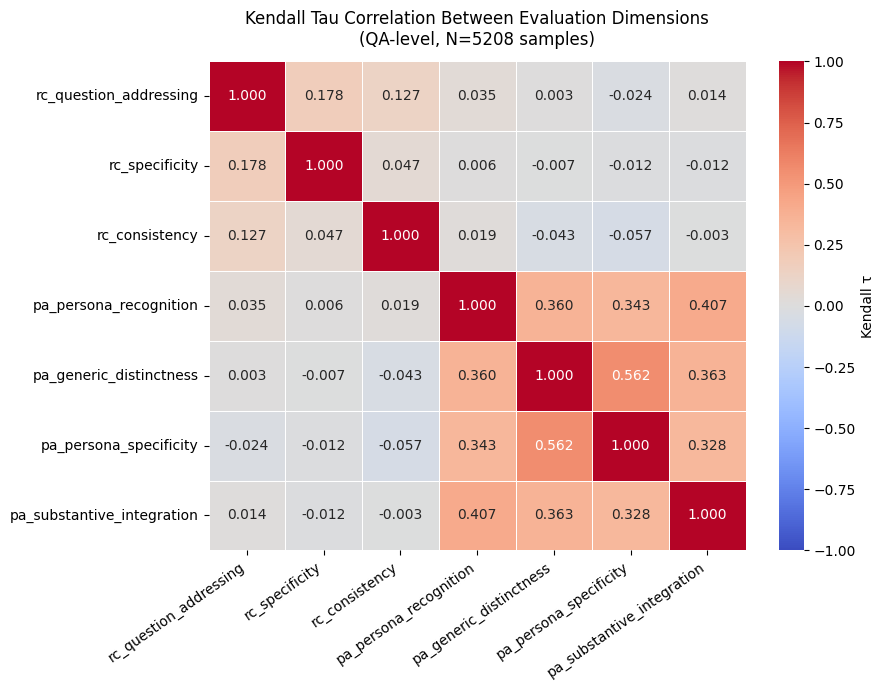

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
annot_k = np.array([
    [f"{kendall_mat[i,j]:.3f}" for j in range(n_dims)]
    for i in range(n_dims)
])
sns.heatmap(
    kendall_df, annot=annot_k, fmt="", cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Kendall τ"},
)
ax.set_title(f"Kendall Tau Correlation Between Evaluation Dimensions\n(QA-level, N={len(kendall_arr)} samples)", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.savefig(BASE_DIR.parent / "kendall_correlation_dims_qa.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Side-by-side comparison

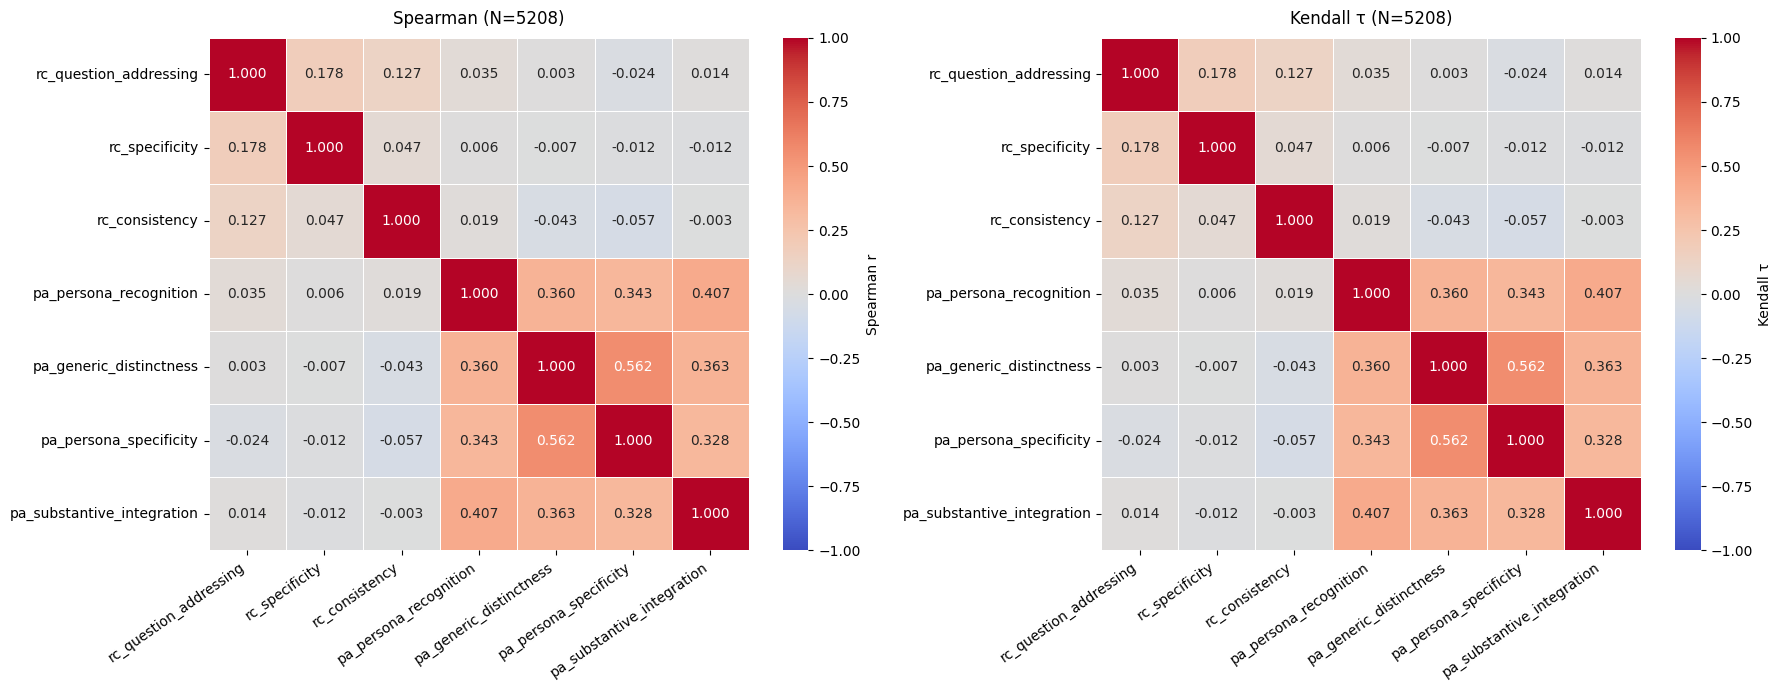

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, mat, title, cbar_label in [
    (axes[0], spearman_mat, f"Spearman (N={len(scores_arr)})", "Spearman r"),
    (axes[1], kendall_mat, f"Kendall τ (N={len(kendall_arr)})", "Kendall τ"),
]:
    annot_data = np.array([
        [f"{mat[i,j]:.3f}" for j in range(n_dims)]
        for i in range(n_dims)
    ])
    df_plot = pd.DataFrame(mat, index=DIMS, columns=DIMS)
    sns.heatmap(
        df_plot, annot=annot_data, fmt="", cmap="coolwarm",
        vmin=-1, vmax=1, linewidths=0.5, ax=ax,
        cbar_kws={"label": cbar_label},
    )
    ax.set_title(f"{title}", pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.savefig(BASE_DIR.parent / "correlation_comparison_qa.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Score distribution per dimension (참고)

In [10]:
score_stats = all_scores[DIMS].agg(["mean", "std", "sum"])
score_stats.loc["count_0"] = (all_scores[DIMS] == 0).sum()
score_stats.loc["count_1"] = (all_scores[DIMS] == 1).sum()
print(f"Score distribution across all QA (N={len(all_scores)}):")
score_stats.round(4)

Score distribution across all QA (N=5208):


,rc_question_addressing,rc_specificity,rc_consistency,pa_persona_recognition,pa_generic_distinctness,pa_persona_specificity,pa_substantive_integration
mean,0.9403,0.7976,0.9814,0.0355,0.0144,0.0265,0.0083
std,0.2370,0.4018,0.1352,0.1851,0.1191,0.1606,0.0905
sum,4897.0000,4154.0000,5111.0000,185.0000,75.0000,138.0000,43.0000
count_0,311.0000,1054.0000,97.0000,5023.0000,5133.0000,5070.0000,5165.0000
count_1,4897.0000,4154.0000,5111.0000,185.0000,75.0000,138.0000,43.0000
